# Exploratory Data Analysis with Principal Component Analysis (PCA)

## Objective

Before performing differential expression analysis, it is important to understand the overall structure of the dataset.

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that summarizes thousands of gene expression measurements into a small number of principal components that capture the largest sources of variation across samples.

In this notebook, PCA is used to:

1. Explore global transcriptional variation among DLBCL patients.
2. Assess whether ABC and GCB subtypes exhibit distinct expression profiles.
3. Investigate whether survival status or disease stage contributes substantially to expression variability.
4. Identify potential outliers that may influence downstream analyses.

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 

In [2]:
expr_df = pd.read_csv("../data/processed/GSE10846_expr_matrx.csv",  index_col=0 )
meta_df = pd.read_csv("../data/processed/GSE10846_metadata.csv",  index_col=0 )

## Selection of Highly Variable Genes

Gene expression datasets contain thousands of genes, many of which show little variation across patients.

To focus PCA on biologically informative signals, the top 1,000 most variable genes were selected based on expression variance across samples.

This approach reduces noise and allows the principal components to capture major biological differences more effectively.

In [3]:
gene_variances = expr_df.var(axis=1)
top_highly_variable_genes = gene_variances.nlargest(1000).index
X_variable = expr_df.loc[top_highly_variable_genes].T

## Data Standardization

PCA is sensitive to differences in scale.

Therefore, gene expression values were standardized so that each gene contributes equally to the analysis regardless of its absolute expression level.

Standardization transforms each gene to have:

- Mean = 0
- Standard Deviation = 1

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_variable)

## Principal Component Analysis

PCA transforms the original high-dimensional gene expression space into a smaller set of orthogonal variables called principal components.

Each principal component captures a proportion of the total variance present in the dataset.

The first two principal components (PC1 and PC2) were used for visualization.

In [5]:
pca = PCA(n_components=2) 

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({ "PC1": pca_result[:, 0], 
                        "PC2": pca_result[:, 1], 
                        "Subtype": meta_df.loc[X_variable.index, "Subtype"], 
                        "Status": meta_df.loc[X_variable.index, "Status"], 
                        "Stage": meta_df.loc[X_variable.index, "Stage"]
                      })

In [6]:
print( 
    f"PC1 Variance Explained: " 
    f"{pca.explained_variance_ratio_[0]:.2%}" 
) 

print( 
    f"PC2 Variance Explained: " 
    f"{pca.explained_variance_ratio_[1]:.2%}" 
)

PC1 Variance Explained: 5.58%
PC2 Variance Explained: 4.17%


## Variance Explained

The first two principal components explained:

- PC1: 5.58% of total variance
- PC2: 4.17% of total variance

Together, the first two components captured approximately 9.66% of the total transcriptional variability.

Although this percentage appears modest, it is common in high-dimensional gene expression datasets where biological variation is distributed across many genes and pathways.

## PCA Colored by Molecular Subtype

To determine whether the major sources of transcriptional variation reflect known DLBCL biology, samples were colored according to molecular subtype (ABC or GCB).

If subtype-specific biology is a major driver of gene expression differences, samples from each subtype should exhibit some degree of separation within PCA space.

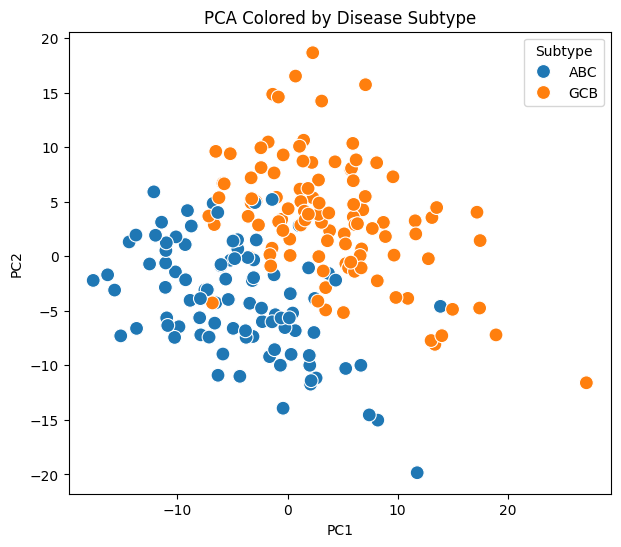

In [7]:
plt.figure(figsize=(7, 6)) 

sns.scatterplot( 
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Subtype", 
    s=100 
) 

plt.title("PCA Colored by Disease Subtype") 

plt.show()

### Interpretation

A noticeable separation between ABC and GCB samples is observed, particularly along PC2.

Key observations:

- ABC and GCB tumors tend to occupy different regions of PCA space.
- Separation is not complete, indicating biological heterogeneity within each subtype.
- Some overlap exists, suggesting that not all transcriptional differences are captured by the first two principal components.
- One potential outlier is visible and may represent an unusual biological profile or technical variation.

Overall, the PCA supports the established view that ABC and GCB DLBCL represent biologically distinct molecular entities with different transcriptional programs.

This finding provides preliminary evidence that differential expression analysis is likely to identify meaningful subtype-associated genes.

## PCA Colored by Survival Status

To investigate whether overall gene expression patterns are associated with patient outcomes, samples were colored according to survival status at follow-up.

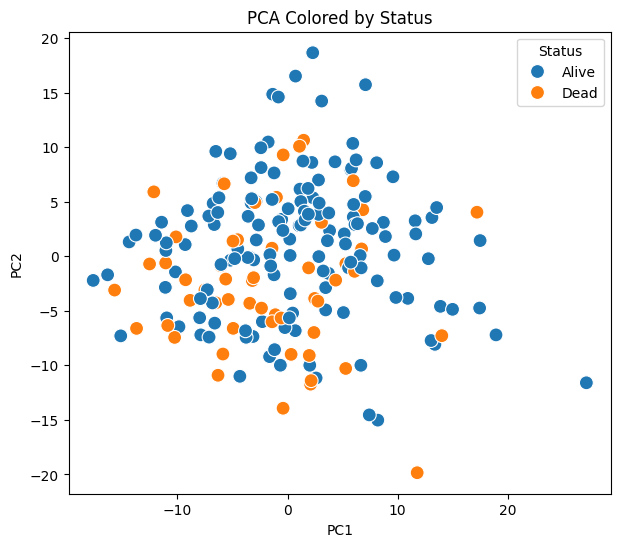

In [8]:
plt.figure(figsize=(7, 6)) 

sns.scatterplot( 
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Status", 
    s=100 
) 

plt.title("PCA Colored by Status") 

plt.show()

### Interpretation

No clear separation is observed between patients who were alive and those who were deceased at follow-up.

Key observations:

- Alive and deceased patients are widely distributed throughout PCA space.
- The two groups show substantial overlap.
- Survival status does not appear to be a dominant source of global transcriptional variation.

This result suggests that survival outcomes may depend on more specific molecular signatures rather than broad transcriptomic patterns captured by the first two principal components.

## PCA Colored by Disease Stage

Disease stage is an important clinical variable that reflects the extent of lymphoma spread.

To determine whether disease stage contributes substantially to global transcriptional variation, samples were colored according to clinical stage.

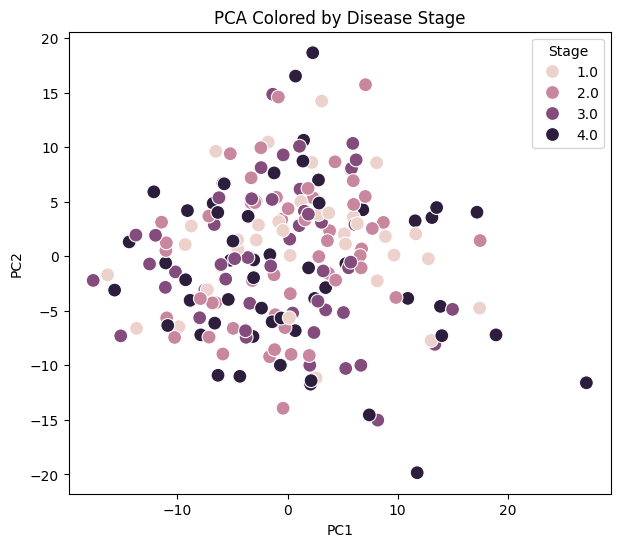

In [9]:
plt.figure(figsize=(7, 6)) 

sns.scatterplot( 
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Stage", 
    s=100 
) 

plt.title("PCA Colored by Disease Stage") 

plt.show()

### Interpretation

No distinct clustering pattern is observed across disease stages.

Key observations:

- Stage I–IV samples are distributed throughout PCA space.
- Considerable overlap exists among all stage groups.
- Disease stage does not appear to be a major determinant of the largest sources of gene expression variation.

These findings suggest that molecular subtype may exert a stronger influence on transcriptional profiles than disease stage within this cohort.

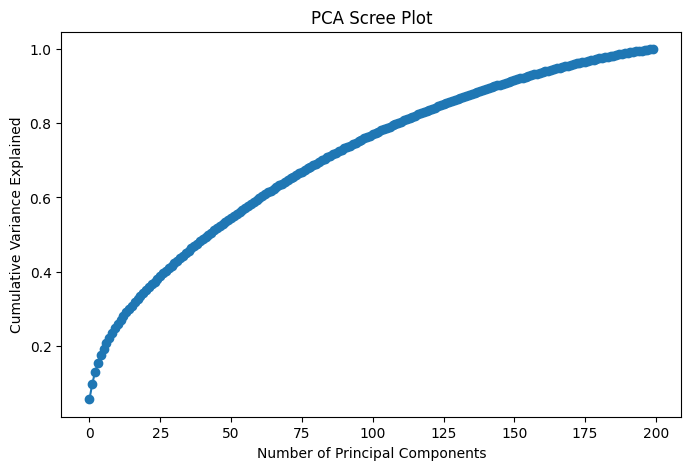

In [10]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Scree Plot")
plt.show()

## Scree Plot

The scree plot shows how much of the total transcriptional variation is captured as additional principal components are included.

Several important patterns emerge:

* The first few principal components capture a substantial amount of variation, as indicated by the steep initial rise of the curve.
* However, variance continues to accumulate gradually across many additional components rather than plateauing early.
* Approximately 75% of the total variance is not captured until around 100 principal components are included.
* More than 120 principal components are required to explain 80–90% of the overall variance.

This pattern indicates that the DLBCL transcriptome is highly complex and influenced by many independent sources of biological variation. Rather than being driven by a small number of dominant expression programs, variability is distributed across numerous genes and pathways.

Consequently, while PC1 and PC2 reveal meaningful subtype-related structure, they capture only a small fraction of the total transcriptomic landscape. Additional principal components likely contain biologically relevant information related to molecular heterogeneity, tumor biology, treatment response, and patient outcomes.


# Conclusions

Principal Component Analysis revealed several important features of the DLBCL cohort:

1. ABC and GCB samples exhibit partial separation, indicating distinct transcriptional programs.
2. Survival status does not strongly influence the dominant axes of gene expression variation.
3. Disease stage similarly shows little association with the first two principal components.
4. Molecular subtype appears to be the strongest biological factor driving transcriptomic differences in this dataset.

These observations justify the next phase of the analysis, where differential expression testing will be performed to identify genes and pathways that distinguish ABC and GCB DLBCL.